# EDA — Phân tích độ lệch giao hàng và sự hài lòng khách hàng

Notebook chính cho phân tích khám phá dữ liệu (EDA).

**Mục tiêu:** phân tích mối quan hệ giữa thời gian giao hàng, SLA và mức độ hài lòng của khách hàng; đồng thời kiểm tra độ ổn định và độ tin cậy của các kết quả.

> Các biểu đồ trong notebook chỉ gọi hàm từ `src/`; logic xử lý và trực quan hóa không được viết lại trong notebook.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Notebook nằm trong notebooks/, đưa thư mục gốc project vào Python path.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.viz.theme import setup_theme
from src.viz.eda import (
    plot_lead_days_hist,
    plot_sla_by_year,
    plot_rating_distribution,
    plot_rating_by_lead_time,
    plot_sla_2x2,
    plot_batch_forest,
    plot_timezone_correction,
    plot_n_vs_neff,
    plot_label_coverage_by_year,
)

setup_theme()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_clean.parquet"

df = pd.read_parquet(DATA_PATH)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data path    : {DATA_PATH}")
print(f"Số dòng      : {len(df):,}")
print(f"Số cột       : {len(df.columns)}")

Project root : d:\project\data_science\datascience_hcmute
Data path    : d:\project\data_science\datascience_hcmute\data\processed\reviews_clean.parquet
Số dòng      : 203,510
Số cột       : 43


## 1. Phân phối Lead Time giao hàng

Phân tích phân phối thời gian giao hàng và vị trí của ngưỡng SLA 5 ngày.

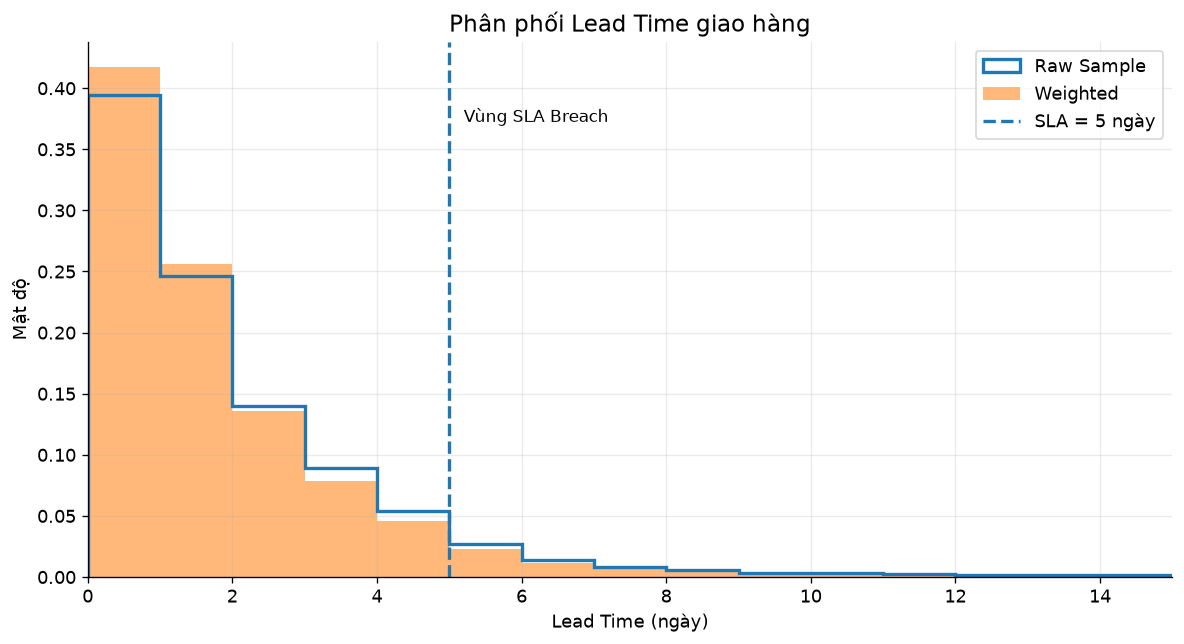

In [2]:
# B4
fig, path_b4 = plot_lead_days_hist(df)
plt.show()

**Kết luận:** Lead Time có phân phối lệch phải; phần lớn đơn hàng nằm trong SLA 5 ngày nhưng vẫn tồn tại đuôi giao hàng kéo dài vượt ngưỡng SLA.

## 2. SLA Breach Rate theo năm

Theo dõi sự thay đổi của tỷ lệ đơn hàng vượt SLA 5 ngày qua các năm.

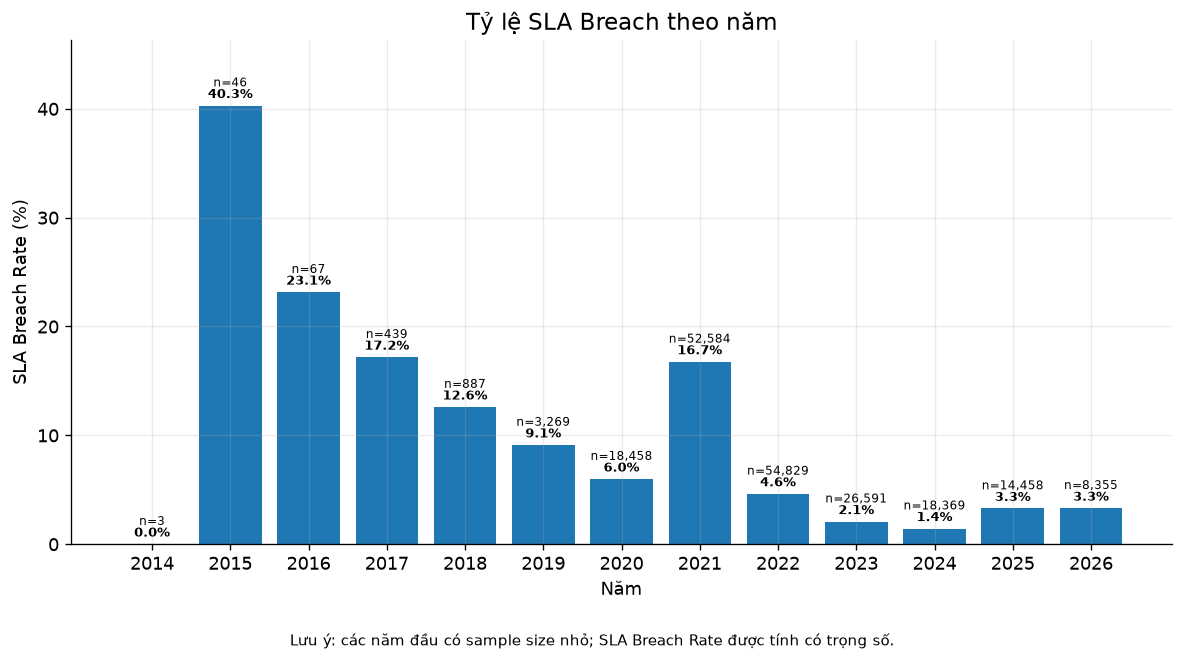

In [3]:
fig, result_b7, path = plot_sla_by_year(df)
plt.show()

**Kết luận:** SLA Breach Rate giảm rõ rệt ở giai đoạn gần đây, trong khi năm 2021 nổi bật với tỷ lệ vượt SLA cao dù có sample size lớn và cần được kiểm tra bằng phân tích sensitivity.

## 3. Phân phối Rating của khách hàng

So sánh phân phối Rating trong Raw Sample với phân phối Weighted sau khi điều chỉnh stratified sampling.

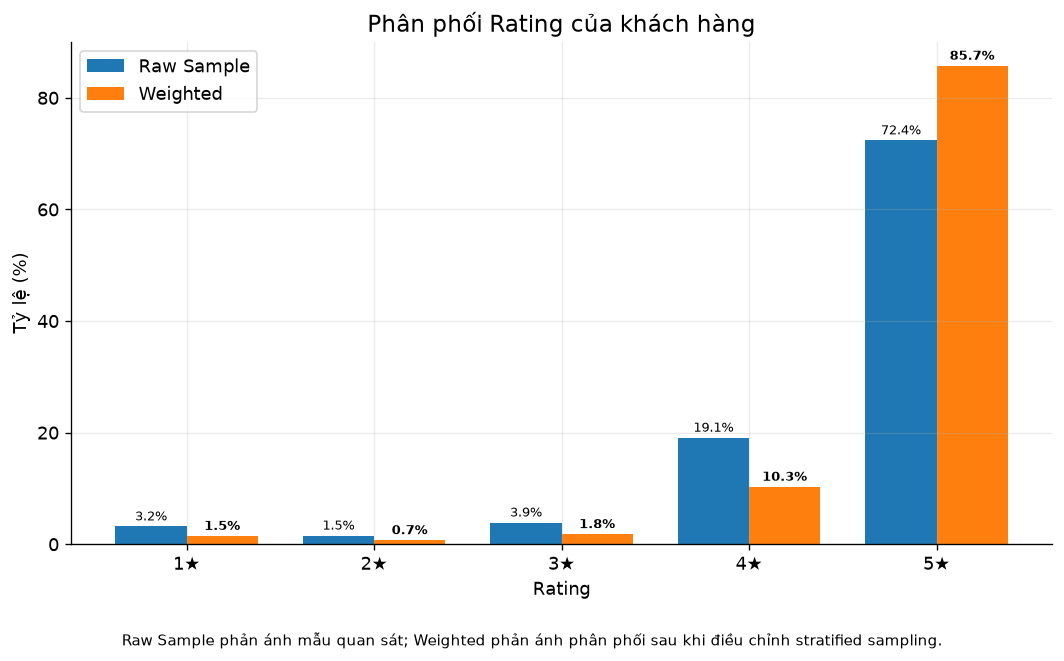

In [4]:
# B8
fig, path_b8 = plot_rating_distribution(df)
plt.show()

**Kết luận:** Sau khi điều chỉnh stratified sampling bằng trọng số, Rating 5★ chiếm tỷ trọng lớn hơn rõ rệt (85,7%), cho thấy Raw Sample không phản ánh trực tiếp phân phối Rating của quần thể.

## 4. Rating theo Lead Time giao hàng

Phân tích sự thay đổi của Weighted Mean Rating theo các khoảng Lead Time, với 95% CI được ước lượng bằng cluster bootstrap.

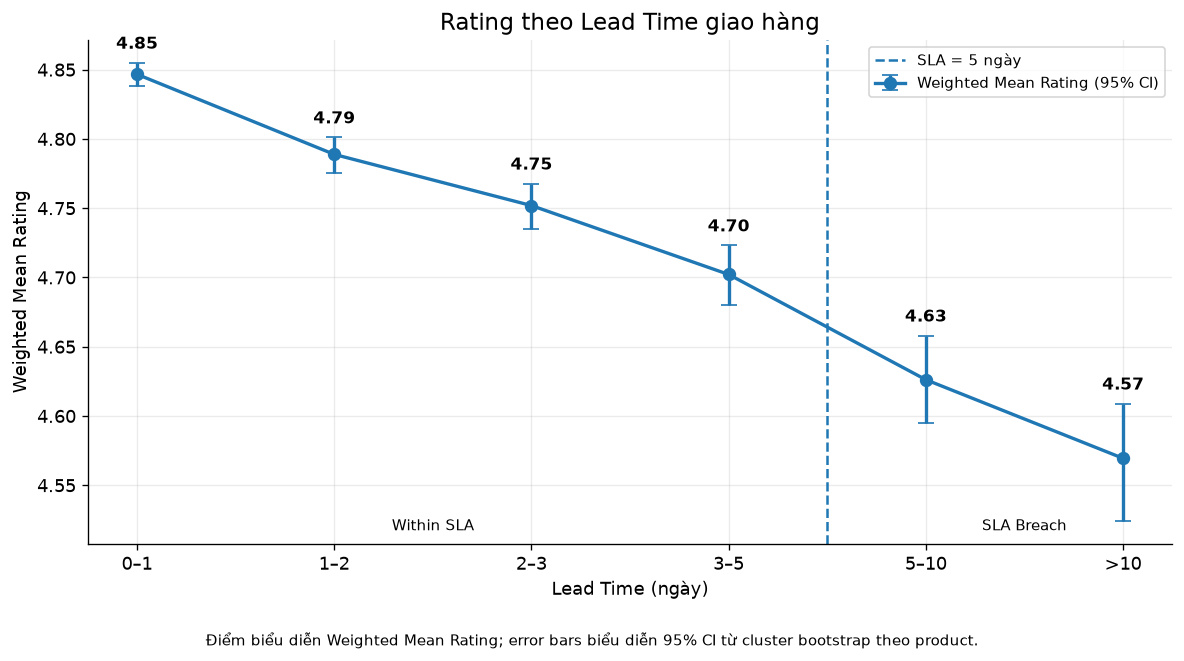

In [5]:
result_b9 = plot_rating_by_lead_time(df)
plt.show()

**Kết luận:** Weighted Mean Rating giảm dần khi Lead Time tăng (từ khoảng 4,85 ở nhóm 0–1 ngày xuống 4,57 ở nhóm >10 ngày), cho thấy thời gian giao hàng dài hơn có liên hệ với mức độ hài lòng thấp hơn, nhưng không hàm ý quan hệ nhân quả.

## 5. Đối chiếu SLA và đánh giá giao hàng của khách hàng

So sánh trạng thái SLA của hệ thống với nhãn giao hàng do khách hàng báo cáo trên tập dữ liệu có label.

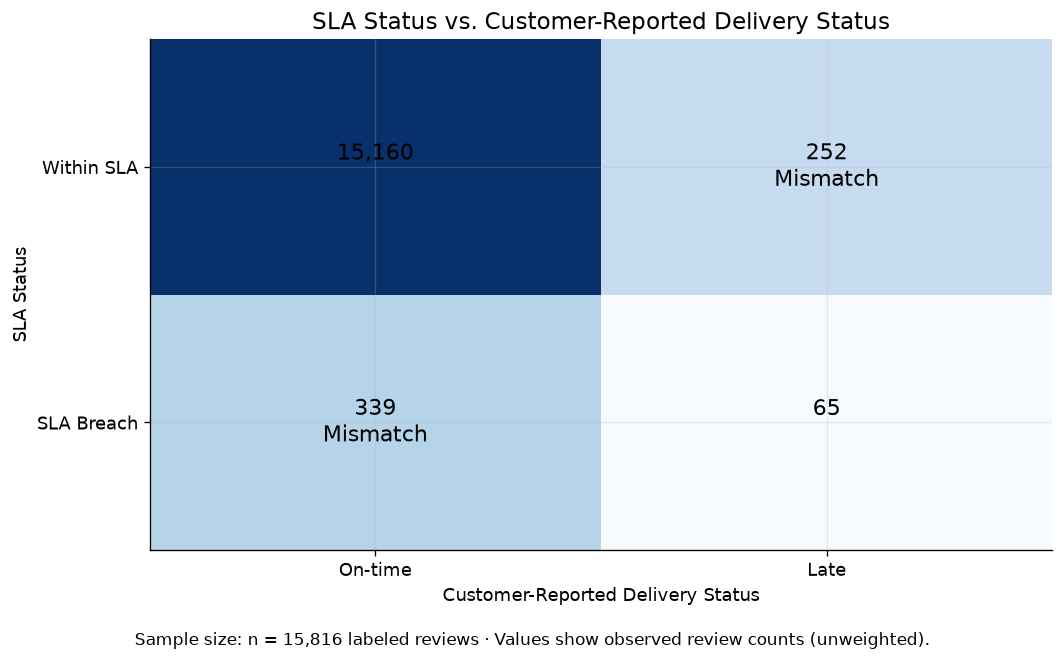

In [6]:
result_b10 = plot_sla_2x2(df)
plt.show()

**Kết luận:** Trong 15.816 reviews có nhãn, SLA và cảm nhận giao hàng của khách hàng nhìn chung đồng thuận, nhưng vẫn xuất hiện các trường hợp không khớp — đặc biệt 252 đơn Within SLA bị khách báo trễ và 339 đơn SLA Breach vẫn được khách báo đúng hẹn.

## 6. Độ ổn định của kết luận chính qua các lần phân tích

Kiểm tra sự ổn định của chênh lệch sức phân biệt giữa nhãn khách hàng và SLA qua các mẻ dữ liệu và sau hiệu chỉnh múi giờ.

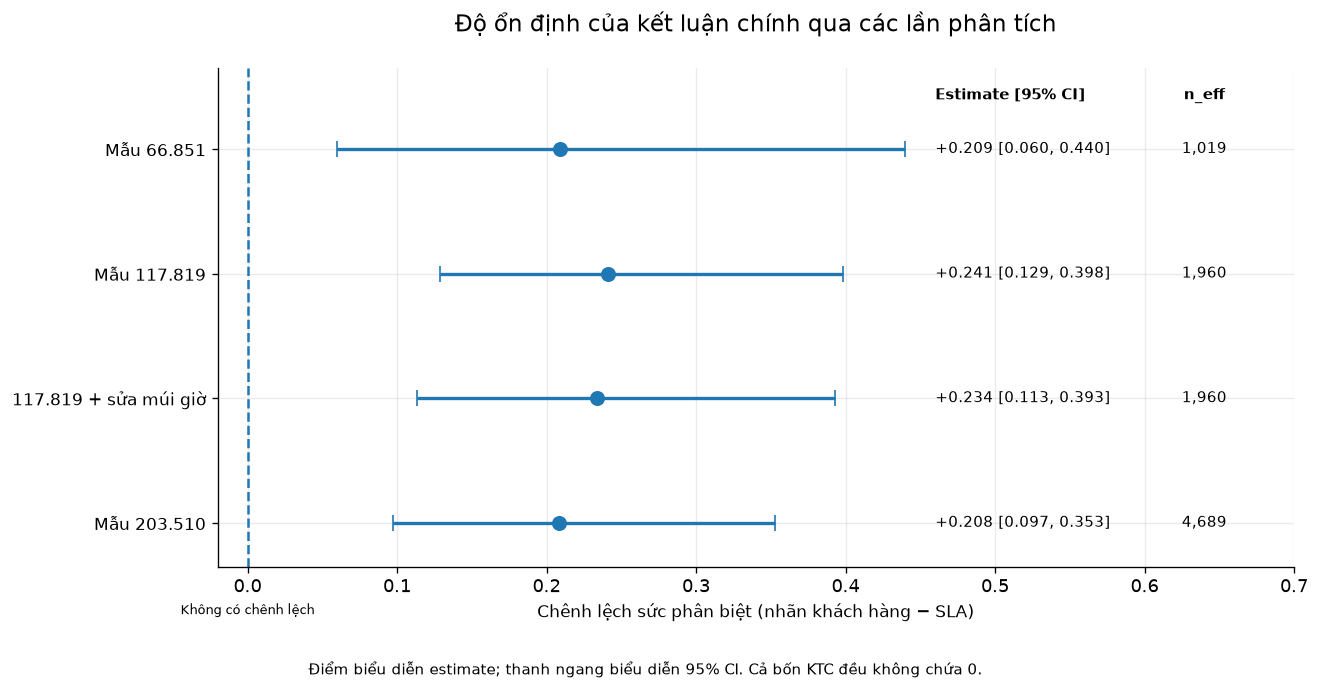

In [7]:
result_b11 = plot_batch_forest()
plt.show()

**Kết luận:** Chênh lệch sức phân biệt giữa nhãn khách hàng và SLA duy trì dương qua cả bốn lần phân tích, với tất cả 95% CI không chứa 0, cho thấy kết luận chính ổn định khi quy mô dữ liệu tăng và sau hiệu chỉnh múi giờ.

## 7. Ảnh hưởng của hiệu chỉnh múi giờ

Kiểm tra mức thay đổi của Lead Time trước và sau khi hiệu chỉnh sai lệch múi giờ giữa hai nguồn thời gian.

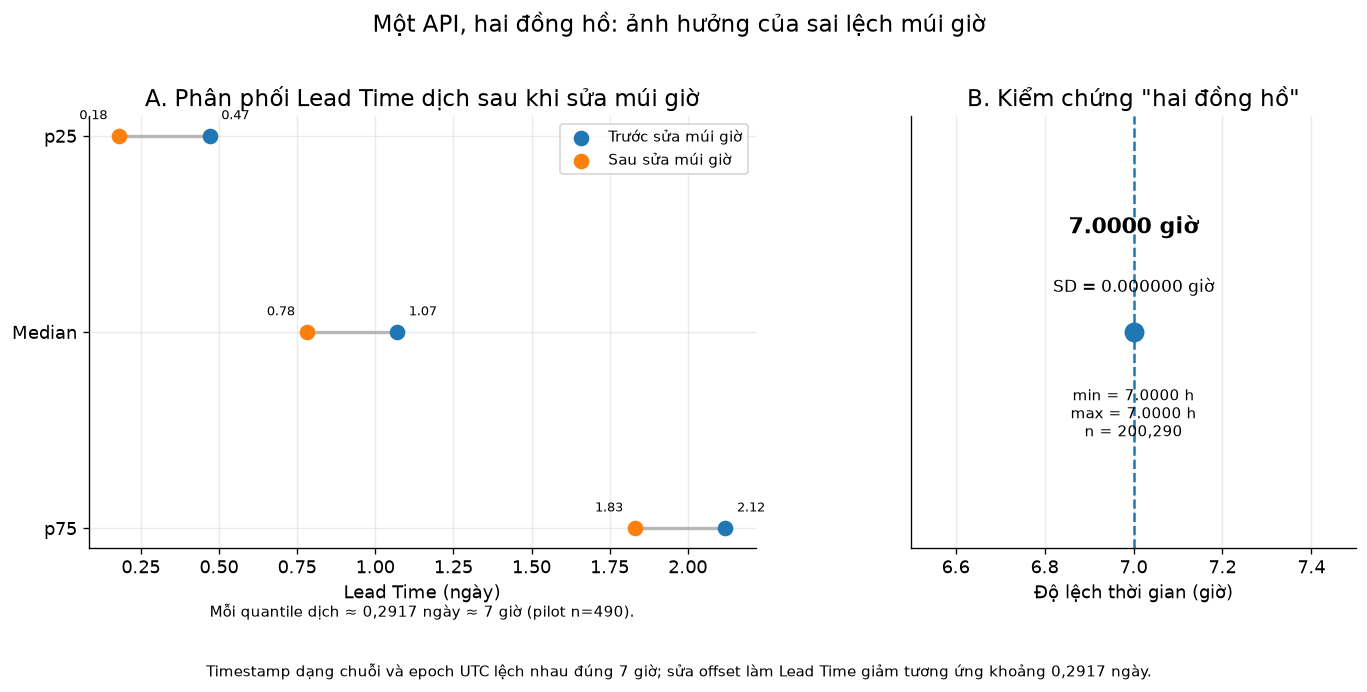

In [8]:
result_b12 = plot_timezone_correction()
plt.show()

**Kết luận:** Hiệu chỉnh múi giờ làm Lead Time giảm khoảng 0,2917 ngày (xấp xỉ 7 giờ), phù hợp với phép kiểm chứng độ lệch đồng hồ 7,0000 giờ trên 200.290 quan sát.

## 8. So sánh cỡ mẫu quan sát và cỡ mẫu hiệu dụng

So sánh số quan sát thực tế (`n`) với Effective Sample Size (`n_eff`) qua ba mẻ dữ liệu để đánh giá mức độ thông tin hiệu dụng sau khi áp dụng trọng số.

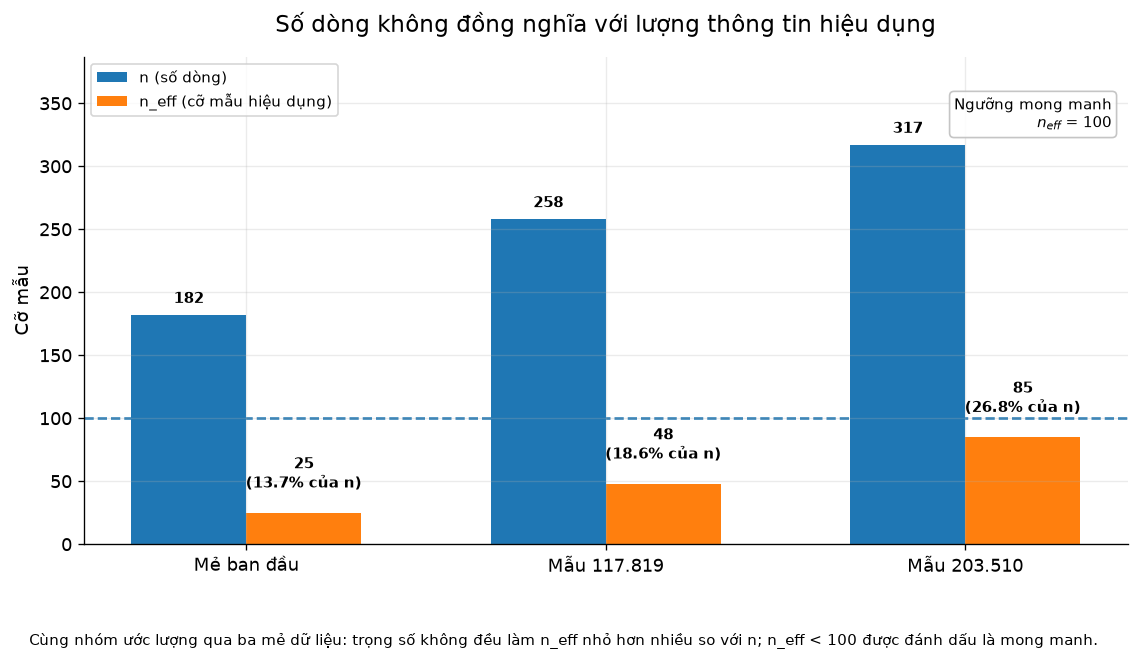

In [9]:
result_b13 = plot_n_vs_neff()
plt.show()

**Kết luận:** Mặc dù số quan sát tăng từ 182 lên 317 qua ba mẻ dữ liệu, `n_eff` chỉ tăng từ 25 lên 85 và vẫn dưới ngưỡng 100, cho thấy ước lượng của nhóm này còn mong manh do trọng số không đồng đều.

## 9. Mức độ bao phủ của Customer-Reported Delivery Label theo năm

Đánh giá mức độ sẵn có của nhãn giao hàng do khách hàng báo cáo theo từng năm và xác định giai đoạn phù hợp cho các phân tích sử dụng label này.

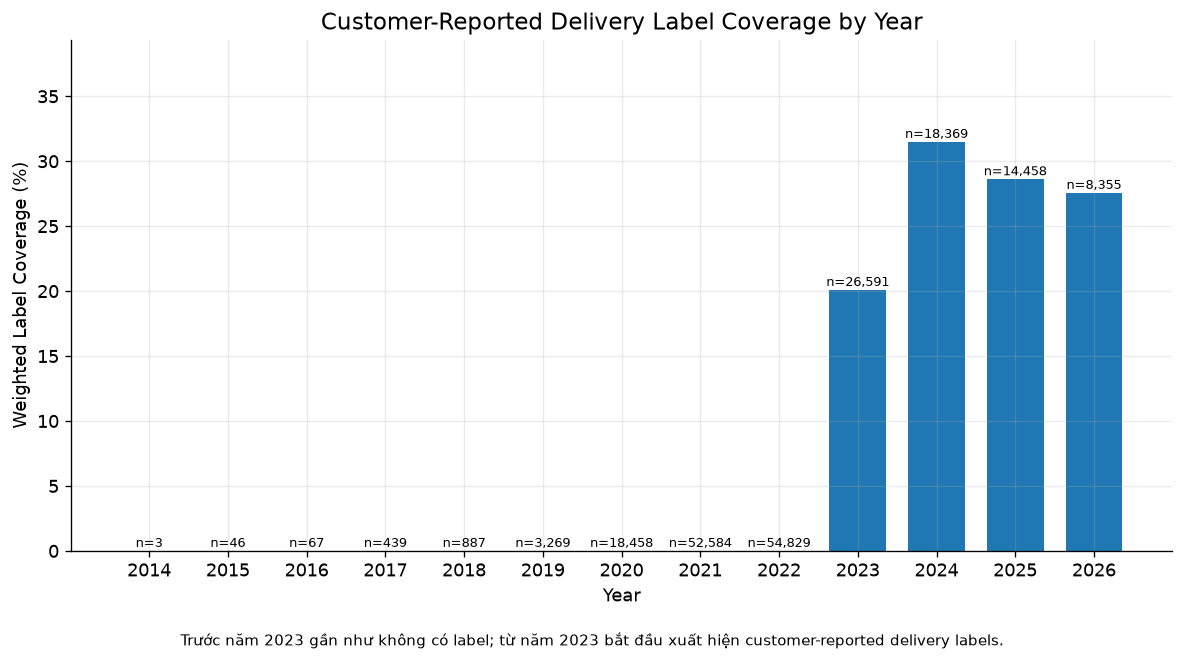

In [10]:
result_b14 = plot_label_coverage_by_year(df)
plt.show()

**Kết luận:** Customer-Reported Delivery Label gần như không tồn tại trước năm 2023 và chỉ đạt khoảng 20–31% Weighted Label Coverage từ 2023 trở đi, vì vậy các phân tích sử dụng label này cần giới hạn ở giai đoạn 2023–2026 và lưu ý nguy cơ selection bias do thiếu nhãn.

## 10. Kết luận EDA

Phân tích EDA cho thấy Lead Time dài hơn có liên hệ với Rating thấp hơn, đồng thời tồn tại sự không đồng nhất giữa SLA của hệ thống và đánh giá giao hàng do khách hàng báo cáo. Kết luận chính duy trì ổn định qua các mẻ dữ liệu, nhưng các phân tích sử dụng Customer-Reported Delivery Label cần tập trung vào giai đoạn 2023–2026 do label gần như không tồn tại trước năm 2023 và vẫn có mức coverage hạn chế.

**Các điểm chính:**
- Lead Time có phân phối lệch phải và vẫn tồn tại các đơn hàng vượt SLA 5 ngày.
- Weighted Mean Rating giảm từ khoảng 4,85 ở nhóm Lead Time 0–1 ngày xuống 4,57 ở nhóm >10 ngày.
- SLA và Customer-Reported Delivery Status không hoàn toàn đồng nhất, cho thấy SLA kỹ thuật chưa phản ánh đầy đủ trải nghiệm giao hàng của khách hàng.
- Kết luận chính ổn định qua các lần phân tích và sau hiệu chỉnh múi giờ.
- `n_eff` nhỏ hơn đáng kể so với `n` ở nhóm ước lượng mong manh, vì vậy cần thận trọng khi diễn giải kết quả của nhóm này.
- Customer-Reported Delivery Label chủ yếu xuất hiện từ năm 2023, do đó các phân tích phụ thuộc vào label cần lưu ý missingness và selection bias.

> **Lưu ý:** Các kết quả EDA thể hiện mối liên hệ quan sát được trong dữ liệu và không được diễn giải như bằng chứng về quan hệ nhân quả.